Simulation configured with 3 defects.
Generating Synthetic Deformation for Multi-Defect Material...
Deformation generated. Max deflection: 1.0497
Training PINN (Multi-Defect)...
Epoch 0: Loss 231.20795
Epoch 500: Loss 0.46008
Epoch 1000: Loss 0.32960
Epoch 1500: Loss 0.28791
Epoch 2000: Loss 0.20683
Epoch 2500: Loss 0.19141
Epoch 3000: Loss 0.09853
Epoch 3500: Loss 0.08395


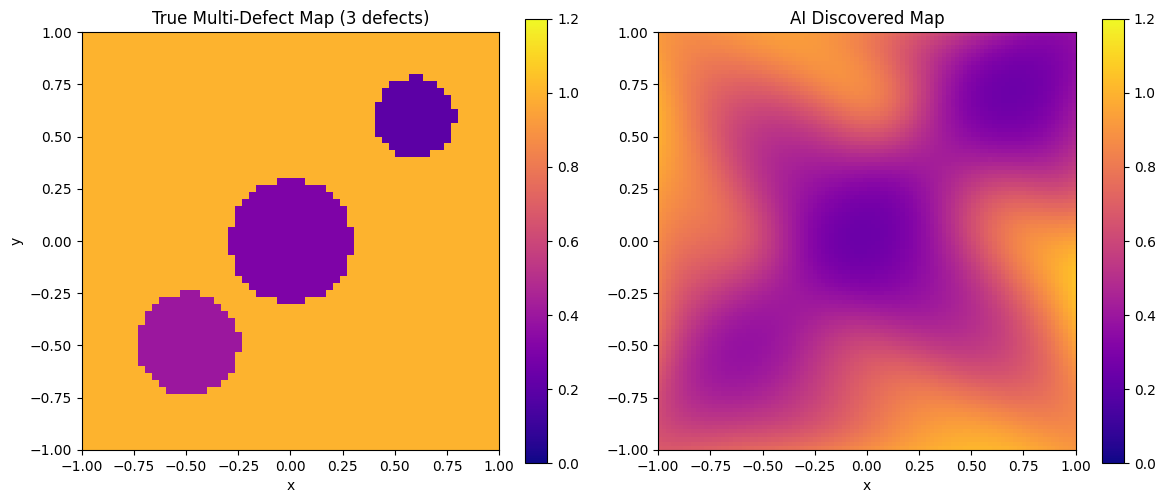

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

defect_list = [
    {'x': 0.0, 'y': 0.0, 'r': 0.3, 'val': 0.3},   # Center weak spot
    {'x': 0.6, 'y': 0.6, 'r': 0.2, 'val': 0.2},   # Top-right severe damage
    {'x': -0.5, 'y': -0.5, 'r': 0.25, 'val': 0.4} # Bottom-left moderate damage
]

print(f"Simulation configured with {len(defect_list)} defects.")

print("Generating Synthetic Deformation for Multi-Defect Material...")

N = 60 # Higher resolution for multiple details
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]

E_true = np.ones((N, N)) # Start with healthy material (E=1.0)

for d in defect_list:

    dist = np.sqrt((X - d['x'])**2 + (Y - d['y'])**2)

    E_true[dist < d['r']] = d['val']

u = np.zeros((N, N))
load = 2.0

for k in range(8000):
    u[1:-1, 1:-1] = 0.25 * (u[0:-2, 1:-1] + u[2:, 1:-1] +
                            u[1:-1, 0:-2] + u[1:-1, 2:] +
                            load * dx**2 / E_true[1:-1, 1:-1])
    u[0, :] = 0; u[-1, :] = 0; u[:, 0] = 0; u[:, -1] = 0

u_true = u
print(f"Deformation generated. Max deflection: {u_true.max():.4f}")

num_samples = 3000 # More samples needed for complex maps
idx_x = np.random.randint(0, N, num_samples)
idx_y = np.random.randint(0, N, num_samples)

x_train = x[idx_x]
y_train = y[idx_y]
u_train = u_true[idx_y, idx_x]


XY_train = np.stack([x_train, y_train], axis=1)
XY_tensor = torch.tensor(XY_train, dtype=torch.float32, requires_grad=True)
u_tensor = torch.tensor(u_train, dtype=torch.float32).view(-1, 1)

class InverseElasticPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Net U: Deformation
        self.net_u = nn.Sequential(
            nn.Linear(2, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )
        self.net_E = nn.Sequential(
            nn.Linear(2, 40), nn.Tanh(),
            nn.Linear(40, 40), nn.Tanh(),
            nn.Linear(40, 40), nn.Tanh(),
            nn.Linear(40, 1),
            nn.Softplus()
        )

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        return self.net_u(inputs), self.net_E(inputs)


def physics_loss(model, x, y):
    u, E = model(x, y)

    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    E_x = torch.autograd.grad(E, x, torch.ones_like(E), create_graph=True)[0]
    E_y = torch.autograd.grad(E, y, torch.ones_like(E), create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]

    equation = E * (u_xx + u_yy) + (E_x * u_x + E_y * u_y) + 2.0

    return torch.mean(equation**2)


model = InverseElasticPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

print("Training PINN (Multi-Defect)...")

x_col = XY_tensor[:, 0:1]
y_col = XY_tensor[:, 1:2]

for epoch in range(4000):
    optimizer.zero_grad()

    u_pred, _ = model(x_col, y_col)
    loss_data = torch.mean((u_pred - u_tensor)**2)

    x_phy = torch.rand(1500, 1) * 2 - 1
    y_phy = torch.rand(1500, 1) * 2 - 1
    x_phy.requires_grad_(True)
    y_phy.requires_grad_(True)

    loss_phy = physics_loss(model, x_phy, y_phy)

    loss = 1000.0 * loss_data + 1.0 * loss_phy
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.5f}")

x_plot = np.linspace(-1, 1, 100)
y_plot = np.linspace(-1, 1, 100)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

x_tens = torch.tensor(X_plot.flatten()[:, None], dtype=torch.float32)
y_tens = torch.tensor(Y_plot.flatten()[:, None], dtype=torch.float32)

_, E_final = model(x_tens, y_tens)
E_pred = E_final.detach().numpy().reshape(100, 100)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title(f"True Multi-Defect Map ({len(defect_list)} defects)")
plt.imshow(E_true, extent=[-1,1,-1,1], origin='lower', cmap='plasma', vmin=0, vmax=1.2)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(1, 2, 2)
plt.title("AI Discovered Map")
plt.imshow(E_pred, extent=[-1,1,-1,1], origin='lower', cmap='plasma', vmin=0, vmax=1.2)
plt.colorbar()
plt.xlabel("x")

plt.tight_layout()
plt.show()

In [ ]:
# This cell creates an animation of sensor placement, but too large to upload in git hub. Run in colab to view results.

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.spatial.distance import cdist
from IPython.display import HTML, display, clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Processing Unit: {device}")

def ground_truth_stiffness(x, y):
    stiffness = np.ones_like(x)
    mask1 = (x - 0.5)**2 + (y - 0.5)**2 < 0.25**2
    mask2 = (x + 0.3)**2 + (y - 0.2)**2 < 0.2**2
    mask3 = (x - 0.2)**2 + (y + 0.6)**2 < 0.15**2

    stiffness[mask1] = 0.5
    stiffness[mask2] = 0.5
    stiffness[mask3] = 0.5
    return stiffness

grid_res = 120
grid_x, grid_y = np.meshgrid(np.linspace(-1, 1, grid_res), np.linspace(-1, 1, grid_res))
truth_map = ground_truth_stiffness(grid_x, grid_y)

flat_grid_x = torch.tensor(grid_x.flatten(), dtype=torch.float32, device=device).unsqueeze(1)
flat_grid_y = torch.tensor(grid_y.flatten(), dtype=torch.float32, device=device).unsqueeze(1)
flat_grid_in = torch.cat([flat_grid_x, flat_grid_y], dim=1)

class RobustNet(nn.Module):
    def __init__(self, scale=1.0):
        super().__init__()
        self.B = nn.Parameter(torch.randn(2, 64, device=device) * scale, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        ).to(device)

    def forward(self, x):
        x_proj = (2. * np.pi * x) @ self.B
        x_mapped = torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)
        return self.net(x_mapped)

def weighted_mse_loss(input, target, weight=20.0):
    loss = (input - target) ** 2
    w_map = torch.ones_like(target)
    w_map[target < 0.8] = weight # Focus on defects
    return torch.mean(loss * w_map)

def train_ensemble(models, x_train, y_train, epochs=500):
    for model in models:
        optimizer = optim.Adam(model.parameters(), lr=0.02)
        for _ in range(epochs):
            optimizer.zero_grad()
            pred = model(x_train)
            loss = weighted_mse_loss(pred, y_train)
            loss.backward()
            optimizer.step()


def get_multi_seed_target(models, candidate_grid_gpu, existing_points_cpu, existing_values_cpu,
                          exclusion_radius=0.1, sweep_radius=0.35):
    preds = []
    with torch.no_grad():
        for model in models:
            preds.append(model(candidate_grid_gpu).cpu().numpy().flatten())
    preds = np.array(preds)
    uncertainty = np.std(preds, axis=0)

    vals = existing_values_cpu.flatten()
    seed_indices = np.where(vals < 0.8)[0]

    candidate_grid_cpu = candidate_grid_gpu.cpu().numpy()

    if len(seed_indices) == 0:
        search_mask = np.ones_like(uncertainty)
    else:
        seed_coords = existing_points_cpu[seed_indices]
        dists = cdist(candidate_grid_cpu, seed_coords)
        min_dist = np.min(dists, axis=1)
        search_mask = (min_dist < sweep_radius).astype(float)

    focused_uncertainty = uncertainty * search_mask

    dists_all = cdist(candidate_grid_cpu, existing_points_cpu)
    min_dist_all = np.min(dists_all, axis=1)
    focused_uncertainty[min_dist_all < exclusion_radius] = 0

    return np.argmax(focused_uncertainty), focused_uncertainty.reshape(grid_res, grid_res), np.max(focused_uncertainty)

print("Initializing Simulation...")

NUM_MODELS = 5
ensemble = [RobustNet(scale=1.0) for _ in range(NUM_MODELS)]

x_init = np.linspace(-0.95, 0.95, 7)
y_init = np.linspace(-0.95, 0.95, 7)
xx, yy = np.meshgrid(x_init, y_init)
x_data = xx.flatten().astype(np.float32)
y_data = yy.flatten().astype(np.float32)
s_data = ground_truth_stiffness(x_data, y_data)

x_train = torch.tensor(np.stack([x_data, y_data], axis=1), dtype=torch.float32, device=device)
y_train = torch.tensor(s_data[:, None], dtype=torch.float32, device=device)

history_frames = []


MAX_STEPS = 150        # Safety limit
UNCERTAINTY_TOL = 0.02 # Stop if max uncertainty drops below this (converged)
patience_counter = 0   # Count steps with low gain

print(f"Starting Adaptive Loop on {device}...")
print(f"Will stop when Uncertainty < {UNCERTAINTY_TOL} or Steps > {MAX_STEPS}")

step = 0
done = False

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
plt.subplots_adjust(wspace=0.15)

while not done:

    train_ensemble(ensemble, x_train, y_train, epochs=250)

    avg_pred = torch.zeros((grid_res*grid_res, 1), device=device)
    with torch.no_grad():
        for m in ensemble: avg_pred += m(flat_grid_in)
    avg_pred /= NUM_MODELS
    pred_map = avg_pred.cpu().numpy().reshape(grid_res, grid_res)

    next_idx, search_map, max_unc = get_multi_seed_target(ensemble, flat_grid_in,
                                               x_train.cpu().numpy(), y_train.cpu().numpy())

    next_x = flat_grid_in[next_idx, 0].item()
    next_y = flat_grid_in[next_idx, 1].item()

    frame_data = {
        'step': step,
        'sensors': x_train.cpu().numpy(),
        'values': y_train.cpu().numpy(),
        'pred_map': pred_map,
        'search_map': search_map,
        'next_target': (next_x, next_y)
    }
    history_frames.append(frame_data)

    clear_output(wait=True)
    axes[0].clear()
    axes[0].set_title(f"Step {step}: Active Sensors ({len(x_train)})", fontsize=14)
    axes[0].contourf(grid_x, grid_y, truth_map, levels=50, cmap='gray', alpha=0.3)
    colors = ['red' if v < 0.8 else 'blue' for v in y_train.cpu().numpy()[:,0]]
    axes[0].scatter(x_train.cpu().numpy()[:,0], x_train.cpu().numpy()[:,1], c=colors, s=80, edgecolors='k')
    axes[0].scatter(next_x, next_y, c='lime', marker='x', s=200, linewidth=4)
    axes[0].set_xlim(-1,1); axes[0].set_ylim(-1,1)

    axes[1].clear()
    axes[1].set_title(f"AI Reconstruction", fontsize=14)
    axes[1].contourf(grid_x, grid_y, pred_map, levels=50, cmap='viridis', vmin=0.2, vmax=1.1)

    axes[2].clear()
    axes[2].set_title(f"Search Map (Max Unc: {max_unc:.4f})", fontsize=14)
    axes[2].contourf(grid_x, grid_y, search_map, levels=50, cmap='inferno')
    axes[2].scatter(next_x, next_y, c='lime', marker='x', s=200, linewidth=4)

    display(fig)
    if max_unc < UNCERTAINTY_TOL:
        patience_counter += 1
        if patience_counter > 3:
            print("CONVERGENCE REACHED: Uncertainty dropped below tolerance.")
            done = True
    else:
        patience_counter = 0 # Reset if we find a high uncertainty spot

    if step >= MAX_STEPS:
        print("STOPPING: Max steps reached.")
        done = True

    if not done:
        val = float(ground_truth_stiffness(next_x, next_y))
        new_pt = torch.tensor([[next_x, next_y]], dtype=torch.float32, device=device)
        new_val = torch.tensor([[val]], dtype=torch.float32, device=device)
        x_train = torch.cat([x_train, new_pt], dim=0)
        y_train = torch.cat([y_train, new_val], dim=0)
        step += 1

print(f"Simulation Finished in {step} steps.")
plt.close()

print("Rendering Final High-Quality Animation...")

fig_anim, axes_anim = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
plt.subplots_adjust(wspace=0.15)

def anim_update(frame_idx):
    data = history_frames[frame_idx]
    for ax in axes_anim: ax.clear()

    # Plot 1
    ax = axes_anim[0]
    ax.set_title(f"Step {data['step']}: Sensor Deployment", fontsize=14)
    ax.contourf(grid_x, grid_y, truth_map, levels=50, cmap='gray', alpha=0.3)
    colors = ['red' if v < 0.8 else 'blue' for v in data['values'][:,0]]
    ax.scatter(data['sensors'][:,0], data['sensors'][:,1], c=colors, s=80, edgecolors='k', zorder=2)
    ax.set_xlim(-1,1); ax.set_ylim(-1,1)

    # Plot 2
    ax = axes_anim[1]
    ax.set_title("AI Reconstruction", fontsize=14)
    ax.contourf(grid_x, grid_y, data['pred_map'], levels=50, cmap='viridis', vmin=0.2, vmax=1.1)

    # Plot 3
    ax = axes_anim[2]
    ax.set_title("Active Learning: Targeted Search", fontsize=14)
    ax.contourf(grid_x, grid_y, data['search_map'], levels=50, cmap='inferno')

    return axes_anim

ani = animation.FuncAnimation(fig_anim, anim_update, frames=len(history_frames), interval=150)
display(HTML(ani.to_jshtml()))

Generating final high-resolution stiffness map...


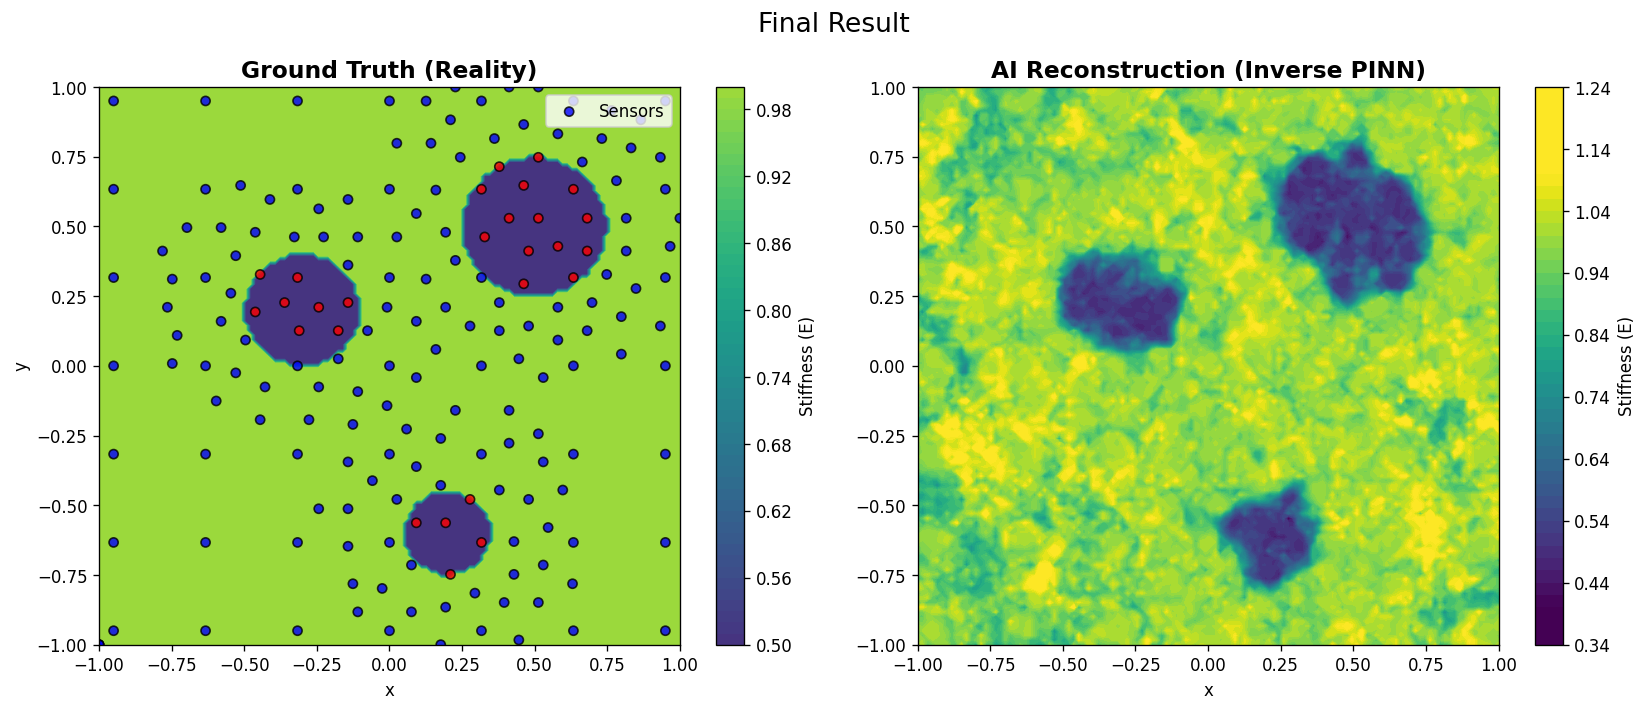

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
grid_res = 120

grid_x, grid_y = np.meshgrid(np.linspace(-1, 1, grid_res), np.linspace(-1, 1, grid_res))

flat_grid_x = torch.tensor(grid_x.flatten(), dtype=torch.float32, device=device).unsqueeze(1)
flat_grid_y = torch.tensor(grid_y.flatten(), dtype=torch.float32, device=device).unsqueeze(1)
flat_grid_in = torch.cat([flat_grid_x, flat_grid_y], dim=1)

def ground_truth_stiffness(x, y):
    stiffness = np.ones_like(x)
    mask1 = (x - 0.5)**2 + (y - 0.5)**2 < 0.25**2
    mask2 = (x + 0.3)**2 + (y - 0.2)**2 < 0.2**2
    mask3 = (x - 0.2)**2 + (y + 0.6)**2 < 0.15**2
    stiffness[mask1] = 0.5; stiffness[mask2] = 0.5; stiffness[mask3] = 0.5
    return stiffness

truth_map = ground_truth_stiffness(grid_x, grid_y)


def show_stiffness_result():
    print("Generating final high-resolution stiffness map...")

    if 'ensemble' not in globals():
        print("Error: 'ensemble' (trained models) not found. Please run the training simulation first.")
        return

    avg_pred = torch.zeros((grid_res*grid_res, 1), device=device)

    with torch.no_grad():
        for m in ensemble:
            avg_pred += m(flat_grid_in)

    pred_map = (avg_pred / len(ensemble)).cpu().numpy().reshape(grid_res, grid_res)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

    im1 = axes[0].contourf(grid_x, grid_y, truth_map, levels=50, cmap='viridis', vmin=0.4, vmax=1.1)
    axes[0].set_title("Ground Truth (Reality)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
    plt.colorbar(im1, ax=axes[0], label="Stiffness (E)")

    if 'x_train' in globals() and 'y_train' in globals():
        sensors = x_train.cpu().numpy()
        readings = y_train.cpu().numpy()
        colors = ['red' if v < 0.8 else 'blue' for v in readings[:,0]]
        axes[0].scatter(sensors[:,0], sensors[:,1], c=colors, s=30, edgecolors='k', alpha=0.8, label="Sensors")
        axes[0].legend(loc='upper right')

    im2 = axes[1].contourf(grid_x, grid_y, pred_map, levels=50, cmap='viridis', vmin=0.4, vmax=1.1)
    axes[1].set_title("AI Reconstruction (Inverse PINN)", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("x")
    plt.colorbar(im2, ax=axes[1], label="Stiffness (E)")

    plt.suptitle(f"Final Result", fontsize=16)
    plt.tight_layout()
    plt.show()

show_stiffness_result()